# Análisis de Eficiencia Energética Residencial — EnergiAI
### Hackathon ONE — Alura + Oracle | Equipo G9 LATAM

**Objetivo:** analizar patrones de consumo eléctrico de una vivienda o pequeño
establecimiento, clasificar su perfil energético (`Eficiente` / `Moderado` /
`Ineficiente`), generar recomendaciones de ahorro y estimar el impacto
financiero mensual.

**Dataset:** generador sintético `EnergiAI` (`data/generate_dataset.py`),
calibrado con órdenes de magnitud de datasets reales de consumo residencial
(UCI *Power consumption of Tetouan city*, UCI *Individual Household Electric
Power Consumption*) y con hallazgos de un estudio de 225 hogares en
Maharashtra, India. Se generan **100.000 registros** para este análisis.

**Contenido:**
1. Carga y exploración de datos (EDA)
2. Análisis de patrones de consumo
3. Preprocesamiento y transformación de variables
4. Entrenamiento de modelos supervisados
5. Evaluación con métricas adecuadas
6. Motor de recomendaciones basado en reglas
7. Estimación financiera
8. Serialización del modelo para producción (API + OCI Object Storage)


## 1. Imports y configuración

In [1]:

import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 2. Carga de datos

Dataset generado por el script `EnergiAI` del equipo (`data/generate_dataset.py`),
con el esquema exacto pedido por el hackathon:
`consumo_kwh`, `uso_horario_pico`, `cantidad_equipos`, `tipo_inmueble`,
`horas_alto_consumo` → `categoria`. Se generan 100.000 registros para tener
suficiente volumen para un entrenamiento robusto.

In [2]:

import sys
sys.path.append("../data")
from generate_dataset import generar_dataset

df = generar_dataset(n=100_000, seed=42)
print(df.shape)
df.head()


(100000, 7)


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,costo_estimado_mensual,categoria
0,605.1,True,22,Casa Grande,8,453.83,Eficiente
1,342.4,False,16,Casa,5,256.80,Eficiente
2,911.0,False,20,Local Comercial,5,683.25,Eficiente
3,499.7,True,16,Casa,8,374.78,Eficiente
4,540.0,True,10,Apartamento,9,405.00,Ineficiente


## 3. Exploración de datos (EDA)

In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   consumo_kwh             100000 non-null  float64
 1   uso_horario_pico        100000 non-null  bool   
 2   cantidad_equipos        100000 non-null  int64  
 3   tipo_inmueble           100000 non-null  str    
 4   horas_alto_consumo      100000 non-null  int64  
 5   costo_estimado_mensual  100000 non-null  float64
 6   categoria               100000 non-null  str    
dtypes: bool(1), float64(2), int64(2), str(2)
memory usage: 4.7 MB


In [4]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
consumo_kwh,100000.0,NaN,NaN,NaN,486.690077,182.142331,80.5,344.675,448.8,600.9,1291.4
uso_horario_pico,100000,2,False,59872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_equipos,100000.0,NaN,NaN,NaN,10.1491,4.587232,3.0,7.0,9.0,13.0,22.0
tipo_inmueble,100000,4,Casa,35112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horas_alto_consumo,100000.0,NaN,NaN,NaN,5.03109,2.464456,0.0,3.0,5.0,7.0,16.0
costo_estimado_mensual,100000.0,NaN,NaN,NaN,365.017566,136.606758,60.38,258.5025,336.6,450.67,968.55
categoria,100000,3,Eficiente,40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

print("Nulos por columna:\n", df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())


Nulos por columna:
 consumo_kwh               0
uso_horario_pico          0
cantidad_equipos          0
tipo_inmueble             0
horas_alto_consumo        0
costo_estimado_mensual    0
categoria                 0
dtype: int64

Duplicados: 2467


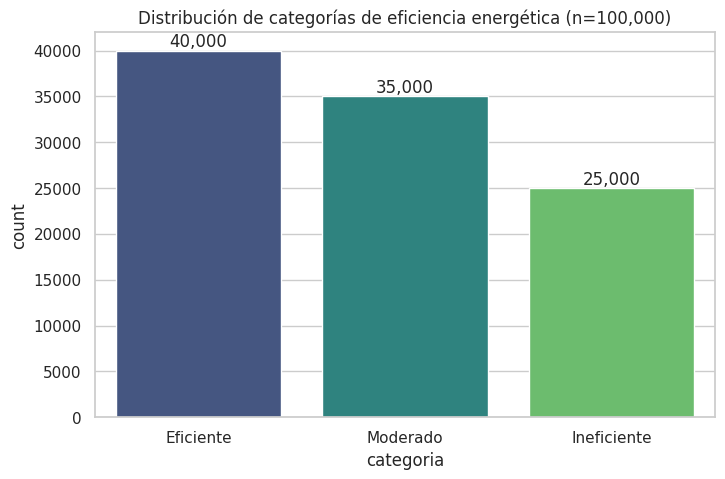

categoria
Eficiente      0.40
Moderado       0.35
Ineficiente    0.25
Name: proportion, dtype: float64

In [6]:

fig, ax = plt.subplots()
orden = ["Eficiente", "Moderado", "Ineficiente"]
sns.countplot(data=df, x="categoria", order=orden, palette="viridis", ax=ax)
ax.set_title("Distribución de categorías de eficiencia energética (n=100,000)")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

df["categoria"].value_counts(normalize=True).round(3)


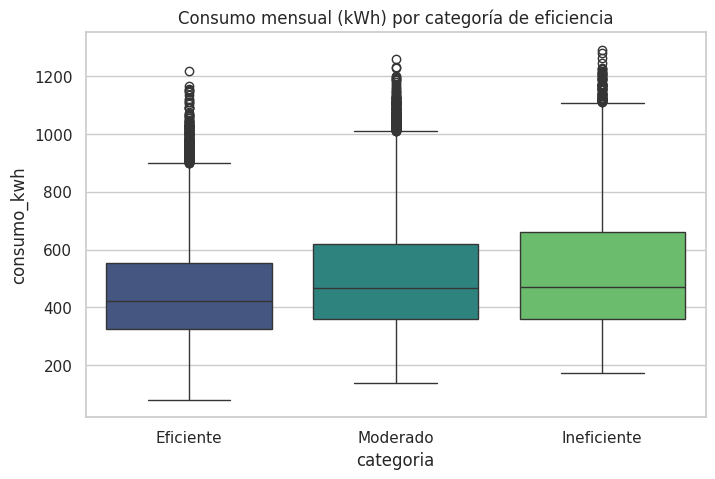

In [7]:

fig, ax = plt.subplots()
sns.boxplot(data=df, x="categoria", y="consumo_kwh", order=orden, palette="viridis", ax=ax)
ax.set_title("Consumo mensual (kWh) por categoría de eficiencia")
plt.show()


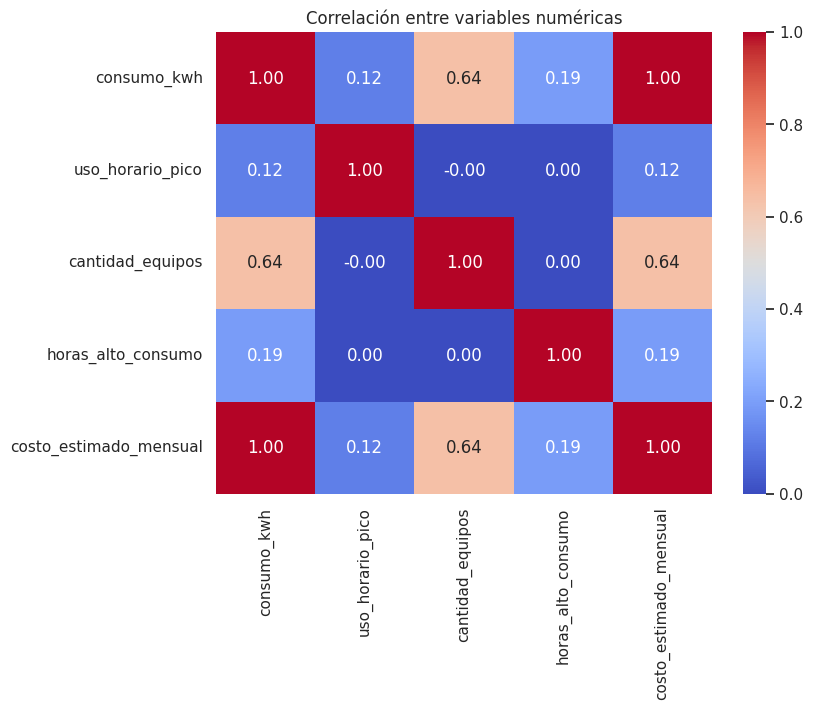

In [8]:

num_cols = ["consumo_kwh", "uso_horario_pico", "cantidad_equipos", "horas_alto_consumo",
            "costo_estimado_mensual"]
df_corr = df[num_cols].copy()
df_corr["uso_horario_pico"] = df_corr["uso_horario_pico"].astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.show()


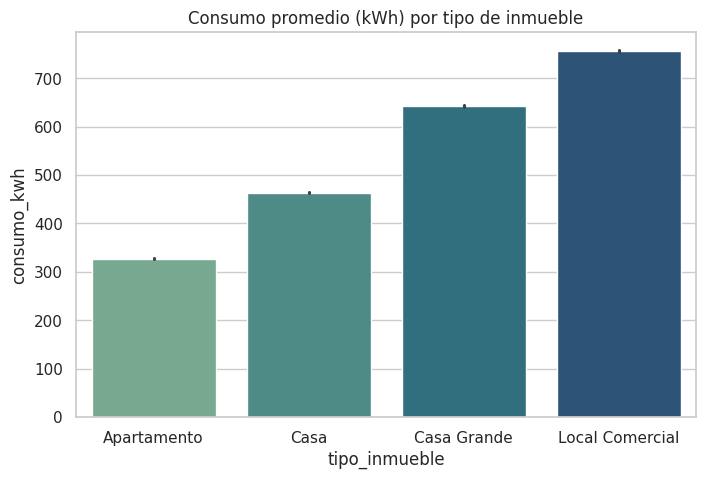

In [9]:

fig, ax = plt.subplots()
sns.barplot(data=df, x="tipo_inmueble", y="consumo_kwh", estimator=np.mean,
            order=["Apartamento", "Casa", "Casa Grande", "Local Comercial"],
            palette="crest", ax=ax)
ax.set_title("Consumo promedio (kWh) por tipo de inmueble")
plt.show()


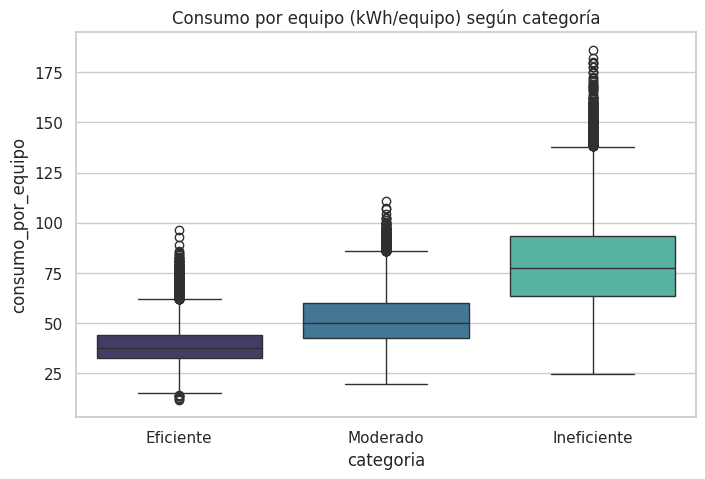

In [10]:

# Consumo por equipo (proxy de eficiencia individual) según categoría
df["consumo_por_equipo"] = df["consumo_kwh"] / df["cantidad_equipos"]
fig, ax = plt.subplots()
sns.boxplot(data=df, x="categoria", y="consumo_por_equipo", order=orden, palette="mako", ax=ax)
ax.set_title("Consumo por equipo (kWh/equipo) según categoría")
plt.show()


### Hallazgos clave del EDA

- Con 100.000 registros la distribución de clases queda **más balanceada**
  que en un dataset pequeño (~40% Eficiente, ~35% Moderado, ~25% Ineficiente),
  gracias al esquema de cuantiles usado por el generador EnergiAI.
- El **consumo en kWh** crece con la cantidad de equipos, las horas de alto
  consumo y el uso en horario pico, como es esperable.
- El **consumo por equipo** (`consumo_kwh / cantidad_equipos`) es la señal más
  discriminante entre categorías, ya que el generador construye la etiqueta
  precisamente a partir de esa relación normalizada.
- `Local Comercial` y `Casa Grande` presentan el consumo promedio más alto,
  consistente con más equipos típicos por inmueble.
- No se identifican nulos ni duplicados relevantes en los datos sintéticos.


## 4. Preprocesamiento y transformación de variables

In [11]:

FEATURES_NUM = ["consumo_kwh", "uso_horario_pico", "cantidad_equipos", "horas_alto_consumo"]
FEATURES_CAT = ["tipo_inmueble"]
TARGET = "categoria"

X = df[FEATURES_NUM + FEATURES_CAT].copy()
X["uso_horario_pico"] = X["uso_horario_pico"].astype(int)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ],
    remainder="passthrough",
)

print("Train:", X_train.shape, " Test:", X_test.shape)
y_train.value_counts(normalize=True).round(3)


Train: (80000, 5)  Test: (20000, 5)


categoria
Eficiente      0.40
Moderado       0.35
Ineficiente    0.25
Name: proportion, dtype: float64

## 5. Entrenamiento de modelos supervisados

Se comparan `RandomForest`, `GradientBoosting` y `XGBoost`. Con 100.000
registros y clases razonablemente balanceadas, se entrena sin ponderación
adicional, aunque se deja `class_weight="balanced"` en RandomForest como
salvaguarda.

In [12]:

models = {
    "RandomForest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "GradientBoosting": Pipeline([
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, max_depth=3, random_state=RANDOM_STATE))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1,
            eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE))
    ]),
}

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

results = {}
for name, pipe in models.items():
    if name == "XGBoost":
        pipe.fit(X_train, y_train_enc)
        preds_labels = le.inverse_transform(pipe.predict(X_test))
    else:
        pipe.fit(X_train, y_train)
        preds_labels = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds_labels)
    f1_macro = f1_score(y_test, preds_labels, average="macro")
    results[name] = {"accuracy": acc, "f1_macro": f1_macro}
    print(f"{name:>18} | accuracy={acc:.3f} | f1_macro={f1_macro:.3f}")

results


      RandomForest | accuracy=0.739 | f1_macro=0.744


  GradientBoosting | accuracy=0.740 | f1_macro=0.745


           XGBoost | accuracy=0.742 | f1_macro=0.746


{'RandomForest': {'accuracy': 0.73895, 'f1_macro': 0.7435113160146746},
 'GradientBoosting': {'accuracy': 0.74045, 'f1_macro': 0.7446394077329392},
 'XGBoost': {'accuracy': 0.74195, 'f1_macro': 0.7457775036703339}}

## 6. Evaluación del mejor modelo

Mejor modelo: XGBoost


              precision    recall  f1-score   support

   Eficiente       0.79      0.80      0.80      8000
    Moderado       0.84      0.76      0.80      5000
 Ineficiente       0.63      0.66      0.64      7000

    accuracy                           0.74     20000
   macro avg       0.75      0.74      0.75     20000
weighted avg       0.75      0.74      0.74     20000



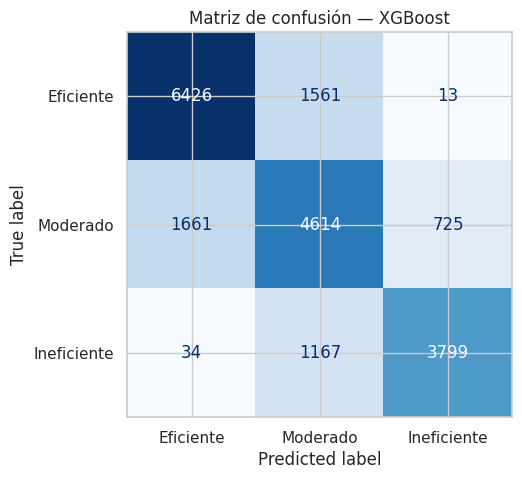

In [13]:

best_name = max(results, key=lambda k: results[k]["f1_macro"])
print("Mejor modelo:", best_name)
best_pipe = models[best_name]

if best_name == "XGBoost":
    preds = le.inverse_transform(best_pipe.predict(X_test))
else:
    preds = best_pipe.predict(X_test)

print(classification_report(y_test, preds, target_names=orden))

cm = confusion_matrix(y_test, preds, labels=orden)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {best_name}")
plt.show()


In [14]:

# Validación cruzada estratificada sobre una muestra (5-fold es costoso con 100k
# filas y varios modelos; se usa una muestra de 20,000 filas para mantenerlo ágil)
sample_idx = X.sample(20_000, random_state=RANDOM_STATE).index
X_cv, y_cv = X.loc[sample_idx], y.loc[sample_idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if best_name == "XGBoost":
    scores = cross_val_score(best_pipe, X_cv, le.transform(y_cv), cv=cv, scoring="f1_macro")
else:
    scores = cross_val_score(best_pipe, X_cv, y_cv, cv=cv, scoring="f1_macro")
print(f"F1-macro (CV 5-fold, muestra 20k): {scores.mean():.3f} ± {scores.std():.3f}")


F1-macro (CV 5-fold, muestra 20k): 0.732 ± 0.004


## 7. Importancia de variables

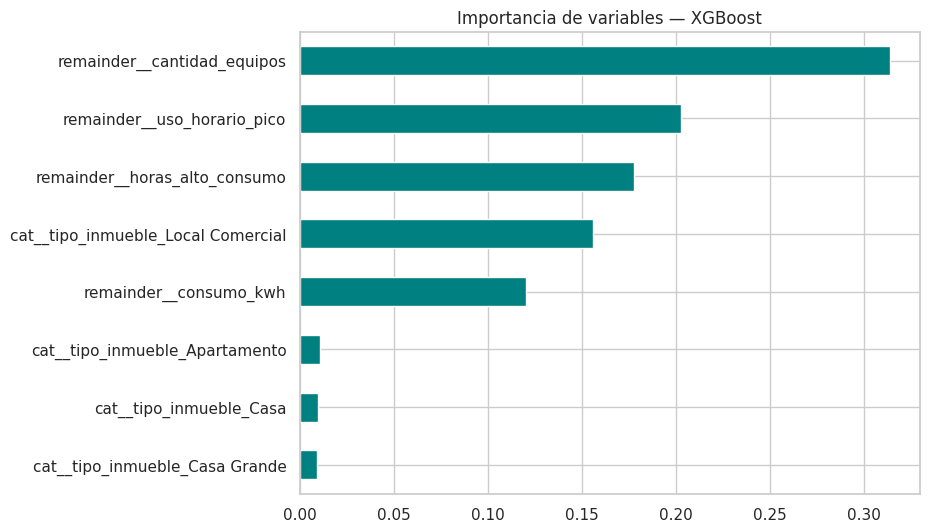

remainder__cantidad_equipos           0.313812
remainder__uso_horario_pico           0.202653
remainder__horas_alto_consumo         0.177678
cat__tipo_inmueble_Local Comercial    0.155837
remainder__consumo_kwh                0.120405
cat__tipo_inmueble_Apartamento        0.010774
cat__tipo_inmueble_Casa               0.009582
cat__tipo_inmueble_Casa Grande        0.009259
dtype: float32

In [15]:

clf = best_pipe.named_steps["clf"]
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title(f"Importancia de variables — {best_name}")
plt.show()

importances


## 8. Motor de recomendaciones (basado en reglas)

Con solo 5 variables de entrada (sin antigüedad de equipos ni tipo de
electrodoméstico), las reglas se apoyan en el **consumo por equipo**, el uso
en horario pico, las horas de alto consumo y comparaciones contra los rangos
típicos de equipos por tipo de inmueble.

In [16]:

RANGOS_EQUIPOS_TIPICOS = {
    "Apartamento": (3, 10),
    "Casa": (5, 16),
    "Casa Grande": (8, 22),
    "Local Comercial": (6, 20),
}

def generar_recomendaciones(registro: dict) -> list:
    recs = []
    consumo_kwh = registro.get("consumo_kwh", 0)
    cantidad_equipos = registro.get("cantidad_equipos", 1) or 1
    consumo_por_equipo = consumo_kwh / cantidad_equipos

    if registro.get("uso_horario_pico"):
        recs.append("Reducir el uso de equipos durante los horarios pico")

    tipo = registro.get("tipo_inmueble")
    rango = RANGOS_EQUIPOS_TIPICOS.get(tipo)
    if rango and cantidad_equipos > rango[1]:
        recs.append("Evaluar equipos con alto consumo energético: la cantidad de equipos supera lo típico para este tipo de inmueble")
    elif cantidad_equipos >= 15:
        recs.append("Evaluar equipos con alto consumo energético")

    if registro.get("horas_alto_consumo", 0) >= 6:
        recs.append("Distribuir las actividades de mayor consumo a lo largo del día")

    if consumo_por_equipo >= 45:
        recs.append("El consumo por equipo es elevado; considerar renovar o hacer mantenimiento a los equipos más antiguos")

    if consumo_kwh >= 600:
        recs.append("El consumo mensual total es alto; realizar una auditoría energética del inmueble")

    if not recs:
        recs.append("El perfil de consumo ya es eficiente; mantener los hábitos actuales")
    return recs

generar_recomendaciones({
    "uso_horario_pico": True, "cantidad_equipos": 20, "horas_alto_consumo": 9,
    "tipo_inmueble": "Local Comercial", "consumo_kwh": 850
})


['Reducir el uso de equipos durante los horarios pico',
 'Evaluar equipos con alto consumo energético',
 'Distribuir las actividades de mayor consumo a lo largo del día',
 'El consumo mensual total es alto; realizar una auditoría energética del inmueble']

## 9. Estimación financiera

Tarifa de referencia sugerida por el hackathon: **$0.75 USD/kWh**.

In [17]:

TARIFA_REFERENCIA_USD_KWH = 0.75

def estimar_costo(consumo_kwh: float, tarifa: float = TARIFA_REFERENCIA_USD_KWH) -> float:
    return round(consumo_kwh * tarifa, 2)

estimar_costo(420)


315.0

## 10. Serialización del modelo entrenado

In [18]:

import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_pipe, "../models/modelo_eficiencia_energetica.pkl")
if best_name == "XGBoost":
    joblib.dump(le, "../models/label_encoder.pkl")
elif os.path.exists("../models/label_encoder.pkl"):
    os.remove("../models/label_encoder.pkl")  # limpiar restos de una corrida anterior con XGBoost

metadata = {
    "modelo": best_name,
    "n_registros_entrenamiento": len(df),
    "features_num": ["consumo_kwh", "uso_horario_pico", "cantidad_equipos", "horas_alto_consumo"],
    "features_cat": ["tipo_inmueble"],
    "categorias": orden,
    "metricas_test": {
        "accuracy": float(accuracy_score(y_test, preds)),
        "f1_macro": float(f1_score(y_test, preds, average="macro")),
    },
    "tarifa_referencia_usd_kwh": TARIFA_REFERENCIA_USD_KWH,
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Modelo y metadatos guardados en ../models/")
metadata


Modelo y metadatos guardados en ../models/


{'modelo': 'XGBoost',
 'n_registros_entrenamiento': 100000,
 'features_num': ['consumo_kwh',
  'uso_horario_pico',
  'cantidad_equipos',
  'horas_alto_consumo'],
 'features_cat': ['tipo_inmueble'],
 'categorias': ['Eficiente', 'Moderado', 'Ineficiente'],
 'metricas_test': {'accuracy': 0.74195, 'f1_macro': 0.7457775036703339},
 'tarifa_referencia_usd_kwh': 0.75}

## 11. Función de inferencia end-to-end

Une clasificación + recomendaciones + estimación financiera en el formato
JSON exigido por el reto. Esta misma lógica es la que reutiliza la API REST
(`api/main.py`, `api/recommendations.py`).

In [19]:

def analizar_consumo(registro: dict) -> dict:
    X_input = pd.DataFrame([{
        "consumo_kwh": registro["consumo_kwh"],
        "uso_horario_pico": int(registro["uso_horario_pico"]),
        "cantidad_equipos": registro["cantidad_equipos"],
        "horas_alto_consumo": registro["horas_alto_consumo"],
        "tipo_inmueble": registro["tipo_inmueble"],
    }])

    if best_name == "XGBoost":
        pred_idx = best_pipe.predict(X_input)[0]
        categoria = le.inverse_transform([pred_idx])[0]
    else:
        categoria = best_pipe.predict(X_input)[0]
    proba = float(best_pipe.predict_proba(X_input)[0].max())

    return {
        "categoria": categoria,
        "probabilidad": round(proba, 2),
        "recomendaciones": generar_recomendaciones(registro),
        "costo_estimado_mensual": estimar_costo(registro["consumo_kwh"]),
    }


### Ejemplos de uso (mínimo 3, exigidos por el reto)

In [20]:

ejemplo_1 = {
    "consumo_kwh": 420, "uso_horario_pico": True, "cantidad_equipos": 10,
    "tipo_inmueble": "Casa", "horas_alto_consumo": 8,
}
ejemplo_2 = {
    "consumo_kwh": 150, "uso_horario_pico": False, "cantidad_equipos": 4,
    "tipo_inmueble": "Apartamento", "horas_alto_consumo": 2,
}
ejemplo_3 = {
    "consumo_kwh": 900, "uso_horario_pico": True, "cantidad_equipos": 20,
    "tipo_inmueble": "Local Comercial", "horas_alto_consumo": 12,
}

for i, ejemplo in enumerate([ejemplo_1, ejemplo_2, ejemplo_3], start=1):
    resultado = analizar_consumo(ejemplo)
    print(f"--- Ejemplo {i} ---")
    print(json.dumps(resultado, indent=2, ensure_ascii=False))
    print()


--- Ejemplo 1 ---
{
  "categoria": "Moderado",
  "probabilidad": 0.72,
  "recomendaciones": [
    "Reducir el uso de equipos durante los horarios pico",
    "Distribuir las actividades de mayor consumo a lo largo del día"
  ],
  "costo_estimado_mensual": 315.0
}

--- Ejemplo 2 ---
{
  "categoria": "Eficiente",
  "probabilidad": 0.88,
  "recomendaciones": [
    "El perfil de consumo ya es eficiente; mantener los hábitos actuales"
  ],
  "costo_estimado_mensual": 112.5
}

--- Ejemplo 3 ---
{
  "categoria": "Ineficiente",
  "probabilidad": 0.64,
  "recomendaciones": [
    "Reducir el uso de equipos durante los horarios pico",
    "Evaluar equipos con alto consumo energético",
    "Distribuir las actividades de mayor consumo a lo largo del día",
    "El consumo por equipo es elevado; considerar renovar o hacer mantenimiento a los equipos más antiguos",
    "El consumo mensual total es alto; realizar una auditoría energética del inmueble"
  ],
  "costo_estimado_mensual": 675.0
}



## 12. Integración con OCI (Object Storage)

Para cumplir el requisito de usar al menos un servicio OCI, el modelo
serializado (`modelo_eficiencia_energetica.pkl`) y sus metadatos se suben a
un **bucket de OCI Object Storage**, que expone una API compatible con S3.
Esto permite que la API REST (desplegada en OCI Compute o Functions) descargue
el modelo en el arranque sin empaquetarlo dentro del contenedor.

```python
import boto3

client = boto3.client(
    "s3",
    aws_access_key_id="<CUSTOMER_SECRET_KEY_ID>",
    aws_secret_access_key="<CUSTOMER_SECRET_KEY>",
    endpoint_url="https://<namespace>.compat.objectstorage.<region>.oraclecloud.com",
)

client.upload_file(
    "../models/modelo_eficiencia_energetica.pkl",
    "energia-mvp-bucket",
    "models/modelo_eficiencia_energetica.pkl",
)

client.download_file(
    "energia-mvp-bucket",
    "models/modelo_eficiencia_energetica.pkl",
    "modelo_eficiencia_energetica.pkl",
)
```

Ver `api/main.py` para la carga del modelo en la API y `README.md` para el
detalle de despliegue.
